## Using chmdata Example 1: Comparing sources of meteorological data

In [ ]:
# imports/setup
import datetime as dt
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Change directory to allow imports internal to the project 
# (remove when using package installed in environment)
root = "C:/Users/CND571/PycharmProjects/chmdata/src"  # <--- Change to your location
os.chdir(root)

import chmdata

### Introduction

- **[AgriMet](https://www.usbr.gov/gp/agrimet/index.html)** is a weather station network that is operated by the US Bureau of Reclamation and has stations in 9 western states, including 35 in Montana. Each station is operated by either the Missouri Basin & Arkansas-Rio Grande-Texas Regional Office or the Columbia-Pacific Northwest Regional Office.

- **[Mesonet](https://climate.umt.edu/mesonet/)** is a weather station and soil moisture network that is operated by the Montana Climate Office. It consists of 178 stations across Montana.

- **[GridMET](https://www.climatologylab.org/gridmet.html)** is a daily ~4km gridded meteorological dataset covering the contiguous US from 1979 to yesterday. It blends information from PRISM and NLDAS-2 reanlaysis products to produce fine spatial and temporal resoution data. 

As of January 2025, there are 3 sets of Mesonet and Agrimet stations that are located close to each other in the state of Montana. This notebook will introduce the functionalities of the chmdata package (particularly the Agrimet, Mesonet, and Gridmet classes) by fetching the data available near Moccasin, MT.

### Generally Useful Functions (Metadata and Utilities)


For the two meterological station networks, there are helper functions that will fetch the metadata for the networks in the form of dictionaries where the keys are the station IDs. Let's take a look at the entries for the Moccasin stations:

In [18]:
# Load all station information
agrimet_stns = chmdata.agrimet.load_stations()
mesonet_stns = chmdata.mesonet.stns_metadata()

In [19]:
# Print single Agrimet station
agrimet_stns['mwsm']

{'geometry': {'coordinates': [-109.950752258301, 47.058536529541],
  'type': 'Point'},
 'id': '130',
 'properties': {'program': 'agrimet',
  'url': 'https://www.usbr.gov/gp/agrimet/station_mwsm_moccasin.html',
  'siteid': 'mwsm',
  'title': 'Moccasin, MT (MWSM)',
  'state': 'MT',
  'type': 'agrimet',
  'region': 'great_plains',
  'install': '06/21/2001'},
 'type': 'Feature'}

In [20]:
# Print single Mesonet station
mesonet_stns['moccasin']

{'name': 'Moccasin',
 'date_installed': '2016-12-18',
 'sub_network': 'AgriMet',
 'longitude': -109.95,
 'latitude': 47.06,
 'elevation': 1294.77,
 'mesowest_id': 'MTM09',
 'gwic_id': None,
 'nwsli_id': None,
 'has_swp': False,
 'funded': True}

We can see some useful information here, like station install dates and coordinates. With this information, as well as another helper function from the "met_utils" module, we can determine how far apart these two stations are:

In [21]:
dist = chmdata.met_utils.great_circle_distance((47.06, -109.95), (47.058536529541, -109.950752258301))
print(f"Distance between Moccasin Agrimet and Mesonet stations: {dist:.2f} km")

Distance between Moccasin Agrimet and Mesonet stations: 0.17 km


While this helps orient us to the available data, the real point of the chmdata package is to actually download meteorological data. Let's see how that works for the Agrimet station. 

### Agrimet Class

In [22]:
agrimet_moc = chmdata.agrimet.Agrimet(station='mwsm')
agrimet_moc_data = agrimet_moc.fetch_met_data()
agrimet_moc_data

,ET,MM,MN,MX,PP,PU,SR,TA,TG,UA,UD,WG,WR,YM
,Modified Penman ETr,Mean Daily Air Temperature,Minimum Daily Air Temperature,Maximum Daily Air Temperature,Daily (24 hour) Precipitation,Accumulated Water Year Precipitation,Daily Global Solar Radiation,Mean Daily Humidity,Growing Degree Days,Daily Average Wind Speed,Daily Average Wind Direction - [deg az],Daily Peak Wind Gust,Daily Wind Run,Mean Daily Dewpoint Temperature
,[mm],[C],[C],[C],[mm],[mm],[MJ m-2],[%],[base 50F],[m sec-1],[deg az],[m sec-1],[m],[C]
DateTime,,,,,,,,,,,,,,
2001-06-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
2001-06-22,NaN,22.450000,13.938889,29.611111,NaN,NaN,NaN,40.73,0.00,2.226259,NaN,NaN,192251.7564,7.511111
2001-06-23,NaN,20.355556,11.700000,27.611111,NaN,NaN,NaN,44.55,0.00,2.548128,NaN,NaN,220222.0856,6.916667
2001-06-24,NaN,19.166667,12.700000,25.777778,NaN,NaN,NaN,44.84,0.00,3.093517,NaN,NaN,267247.0004,6.566667
2001-06-25,NaN,15.744444,7.350000,22.555556,NaN,NaN,NaN,48.20,0.00,4.077005,NaN,NaN,352316.7128,3.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-13,9.652,22.500000,11.988889,31.000000,NaN,NaN,29.24616,41.33,19.79,3.147162,NaN,NaN,271978.4600,7.350000


All of the data-fetching functions in the package return the time series as pandas dataframes. To take a closer look at this data, you can uncomment the code below.

In [23]:
# # checking agrimet data
# for col in agrimet_moc_data.columns:
#     # print(col)
#     plt.figure()
#     plt.title(f"{col[0]}: {col[1]}")
#     plt.plot(agrimet_moc_data[col[0]])
#     plt.xlim(dt.date(2016, 1, 1), dt.date(2020, 1, 1))
#     plt.ylabel(col[2])
#     plt.show()

By default, the Agrimet object selects all available variables and the full period of record. Customizing these options involves just a few keyword arguments. For example, here we will just download air temperature and precipitation for 2024.

In [24]:
agrimet_moc_1 = chmdata.agrimet.Agrimet(station='mwsm', start_date="2024-01-01", end_date="2024-12-31")
agrimet_moc_data_1 = agrimet_moc_1.fetch_met_data(params=["MM", "PP"])
agrimet_moc_data_1

,MM,PP
,Mean Daily Air Temperature,Daily (24 hour) Precipitation
,[C],[mm]
DateTime,,
2024-01-01,-0.650000,NaN
2024-01-02,-1.988889,NaN
2024-01-03,-2.883333,NaN
2024-01-04,-0.761111,NaN
2024-01-05,-2.550000,NaN
...,...,...
2024-12-27,1.716667,NaN


### Mesonet Class

Downloading mesonet data is very similar, except the dataframe is stored as an attribute of the mesonet object, instead of returning a separate object.

In [25]:
mesonet_moc = chmdata.mesonet.Mesonet(stn_id='moccasin')
mesonet_moc.get_data()  # This takes about 5 minutes.
mesonet_moc.data

moccasin install date: 2016-12-18


,station,Air Temperature @ 8 ft [°F],Precipitation [in],Max Precip Rate [in/h],Atmospheric Pressure [mbar],Relative Humidity [%],Soil Temperature @ -5 cm [°F],Soil Temperature @ -10 cm [°F],Soil Temperature @ -20 cm [°F],Soil Temperature @ -50 cm [°F],...,Bulk EC @ -20 cm [mS/cm],Bulk EC @ -50 cm [mS/cm],Bulk EC @ -91 cm [mS/cm],Solar Radiation [W/m²],VPD [mbar],Wind Direction @ 8 ft [deg],Wind Speed @ 10 m [mi/h],Wind Speed @ 8 ft [mi/h],Gust Speed @ 10 m [mi/h],Gust Speed @ 8 ft [mi/h]
2016-12-19,moccasin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-20,moccasin,35.205,0.000,0.000,865.770,58.175,NaN,29.179,30.458,34.880,...,NaN,NaN,NaN,34.940,NaN,234.154,NaN,12.125,NaN,52.814
2016-12-21,moccasin,29.382,0.000,0.000,873.899,52.859,NaN,25.025,30.622,34.880,...,NaN,NaN,NaN,64.838,NaN,55.050,NaN,9.336,NaN,26.195
2016-12-22,moccasin,33.096,0.000,0.000,866.947,34.250,NaN,27.739,30.422,34.880,...,NaN,NaN,NaN,55.316,NaN,26.814,NaN,12.501,NaN,26.396
2016-12-23,moccasin,27.448,0.000,0.000,860.970,51.578,NaN,23.555,30.358,34.879,...,NaN,NaN,NaN,29.366,NaN,33.497,NaN,4.912,NaN,16.441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,moccasin,35.090,0.000,0.000,855.948,53.232,NaN,34.034,34.376,37.400,...,0.394,0.232,0.039,58.648,3.408,252.060,NaN,11.836,NaN,35.836
2024-12-28,moccasin,37.816,0.000,0.000,859.504,61.488,NaN,34.122,34.308,37.362,...,0.395,0.232,0.039,49.764,3.126,241.206,NaN,12.248,NaN,36.574
2024-12-29,moccasin,33.027,0.002,0.000,860.004,NaN,NaN,33.995,34.293,37.389,...,0.395,0.233,0.039,14.917,1.206,222.208,NaN,7.856,NaN,26.396
2024-12-30,moccasin,22.604,0.000,0.000,870.579,NaN,NaN,34.029,34.197,37.284,...,0.396,0.232,0.039,39.745,0.027,332.457,NaN,9.811,NaN,35.254


In [26]:
# # checking mesonet data
# for col in mesonet_moc.data.columns:
#     # print(col)
#     plt.figure()
#     plt.title(f"{col[0]}: {col[1]}")
#     plt.title(col)
#     plt.plot(mesonet_moc.data[col])
#     # plt.xlim(dt.date(2016, 1, 1), dt.date(2020, 1, 1))
#     # plt.ylabel(col[2])
#     plt.show()

Again, the default behavior is to get all available parameters for the entire period of record, but this can easily be changed with some keyword arguments like this:

In [27]:
mesonet_moc_1 = chmdata.mesonet.Mesonet(stn_id='moccasin')
mesonet_moc_1.get_data(elems=["air_temp_0244", "ppt"], 
                     start="2024-01-01", end="2024-12-31")  # This takes about 5 minutes.
mesonet_moc_1.data

,station,Air Temperature @ 8 ft [°F],Precipitation [in]
2024-01-01,moccasin,30.123,0.000
2024-01-02,moccasin,27.166,0.000
2024-01-03,moccasin,25.687,0.000
2024-01-04,moccasin,30.067,0.000
2024-01-05,moccasin,26.771,0.000
...,...,...,...
2024-12-26,moccasin,38.180,0.000
2024-12-27,moccasin,35.090,0.000
2024-12-28,moccasin,37.816,0.000
2024-12-29,moccasin,33.027,0.002


### Gridmet Class

Now that we've gotten our station data, let's compare with the GridMET data. For GridMET, you can only download one variable with the same object, so all we need to do is loop over the variables we want data for, then save each time series as a separate column in the final dataframe.

In [28]:
gm_vars = ['etr', 'pet', 'pr', 'rmax', 'rmin', 'srad', 'th', 'tmmn', 'tmmx', 'vs']
gridmet_moc_data = pd.DataFrame()
for v in gm_vars:  # can only download one variable at a time.
    gridmet_moc = chmdata.thredds.GridMet(variable=v, start='2001-01-01', 
                                        end='2025-06-25', lat=47.06, lon=-109.95)
    gridmet_moc_d = gridmet_moc.get_point_timeseries()
    gridmet_moc_data[v] = gridmet_moc_d
gridmet_moc_data

,etr,pet,pr,rmax,rmin,srad,th,tmmn,tmmx,vs
2001-01-01,2.1,1.3,0.0,89.900002,47.600002,64.099998,273.0,267.100006,278.000000,7.1
2001-01-02,2.9,1.7,0.0,86.900002,40.299999,59.000000,269.0,265.799988,279.799988,6.9
2001-01-03,3.8,2.3,0.0,67.700005,30.200001,59.700001,273.0,273.000000,282.600006,7.3
2001-01-04,3.6,2.2,0.0,74.400002,25.800001,51.700001,276.0,273.200012,282.100006,7.9
2001-01-05,4.8,2.8,0.0,80.700005,30.600000,63.000000,268.0,273.299988,285.799988,8.5
...,...,...,...,...,...,...,...,...,...,...
2025-06-21,5.2,4.1,0.0,97.900002,43.700001,304.300018,264.0,277.299988,290.399994,4.9
2025-06-22,1.2,1.2,2.5,100.000000,85.400002,190.100006,289.0,273.500000,279.899994,5.4
2025-06-23,5.9,4.5,0.0,90.599998,33.500000,302.800018,258.0,275.600006,291.200012,4.7
2025-06-24,6.3,5.0,0.0,79.200005,27.500000,311.200012,198.0,279.200012,295.899994,2.5


In [29]:
# # checking gridmet data
# for col in gridmet_moc_data.columns:
#     # print(col)
#     plt.figure()
#     plt.title(f"{col}: {gridmet_moc.kwords[col]}")
#     plt.plot(gridmet_moc_data[col])
#     # plt.xlim(dt.date(2016, 1, 1), dt.date(2020, 1, 1))
#     plt.ylabel(gridmet_moc.units[col])
#     plt.show()

### Data Comparison

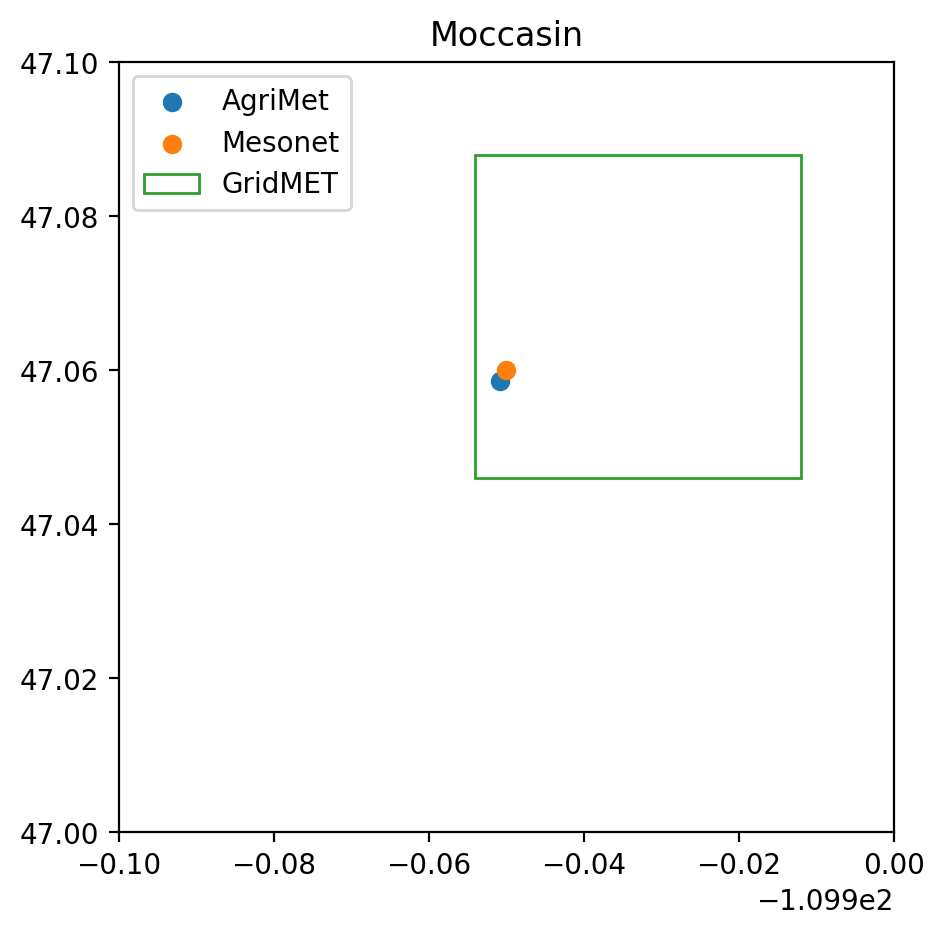

In [30]:
# It's a start.

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=200)
ax.set_title('Moccasin')
ax.scatter(agrimet_moc.station_coords[1], agrimet_moc.station_coords[0], label='AgriMet')
ax.scatter(mesonet_moc.lon, mesonet_moc.lat, label='Mesonet')
ax.add_patch(matplotlib.patches.Rectangle((gridmet_moc.lon - 0.021, gridmet_moc.lat - 0.021), 0.042, 0.042, ec='tab:green', fill=0, label='GridMET'))
# ax.scatter(gridmet_moc.lon, gridmet_moc.lat, label='GridMET centroid')
ax.set_xlim(-110, -109.9)
ax.set_ylim(47, 47.1)
ax.legend()
plt.show()

In [31]:
# Info on variables for the different data sources
print(f"GridMet {len(gridmet_moc_data.columns)}:")
for i in gridmet_moc_data.columns:
    print(f"{i}: {gridmet_moc.kwords[i]} [{gridmet_moc.units[i]}]")
print(f"\nMesonet {len(mesonet_moc.data.columns)}:")
print(mesonet_moc.data.columns)
print(f"\nAgrimet {len(agrimet_moc_data.columns)}:")
print(agrimet_moc_data.columns)

GridMet 10:
etr: daily_mean_reference_evapotranspiration_alfalfa [mm]
pet: daily_mean_reference_evapotranspiration_grass [mm]
pr: precipitation_amount [mm]
rmax: daily_maximum_relative_humidity [%]
rmin: daily_minimum_relative_humidity [%]
srad: daily_mean_shortwave_radiation_at_surface [w/m^2]
th: daily_mean_wind_direction [degrees]
tmmn: daily_minimum_temperature [k]
tmmx: daily_maximum_temperature [k]
vs: daily_mean_wind_speed [m/s]

Mesonet 28:
Index(['station', 'Air Temperature @ 8 ft [°F]', 'Precipitation [in]',
       'Max Precip Rate [in/h]', 'Atmospheric Pressure [mbar]',
       'Relative Humidity [%]', 'Soil Temperature @ -5 cm [°F]',
       'Soil Temperature @ -10 cm [°F]', 'Soil Temperature @ -20 cm [°F]',
       'Soil Temperature @ -50 cm [°F]', 'Soil Temperature @ -91 cm [°F]',
       'Soil VWC @ -5 cm [%]', 'Soil VWC @ -10 cm [%]',
       'Soil VWC @ -20 cm [%]', 'Soil VWC @ -50 cm [%]',
       'Soil VWC @ -91 cm [%]', 'Bulk EC @ -5 cm [mS/cm]',
       'Bulk EC @ -10 cm 

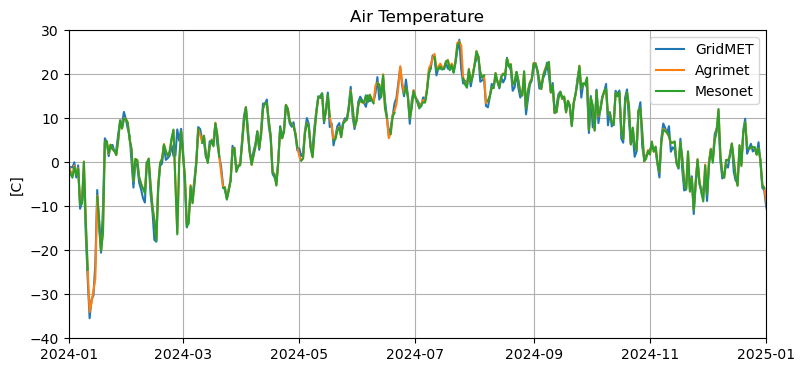

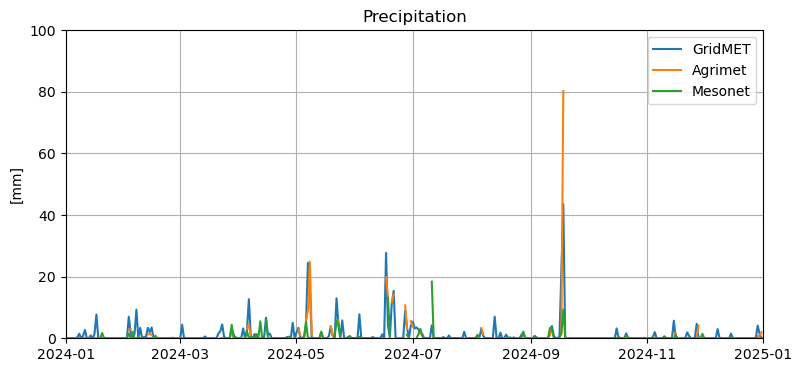

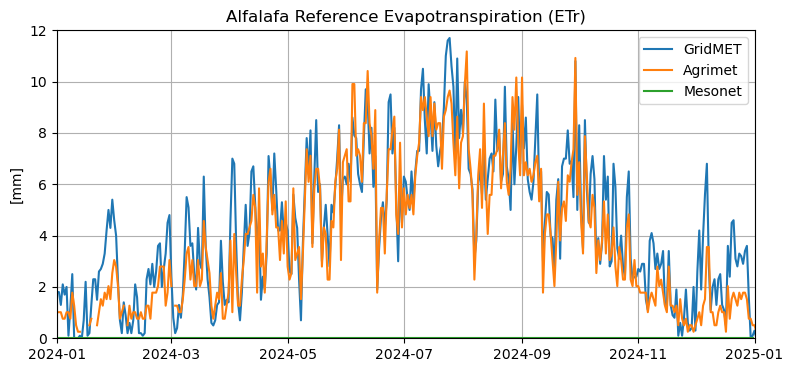

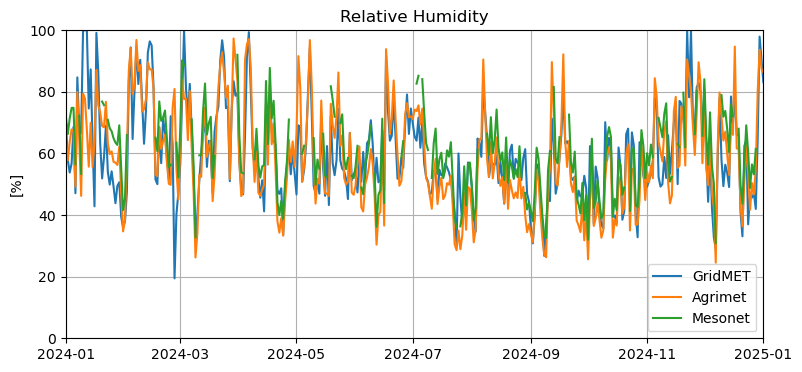

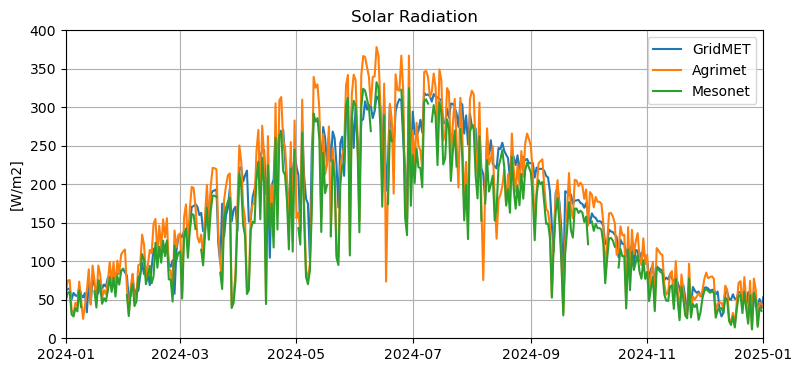

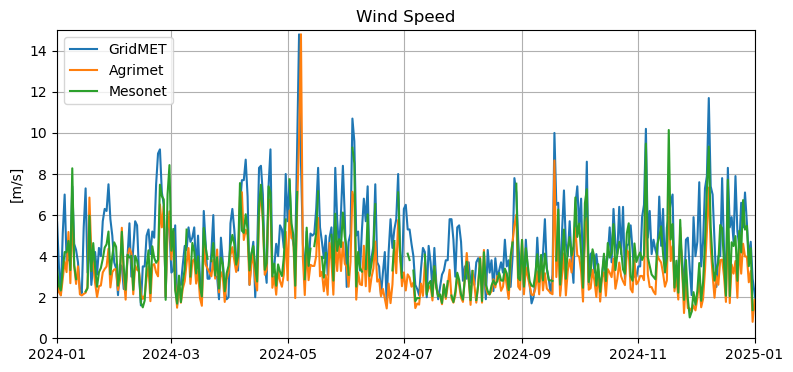

In [32]:
# Adjust plotting limits here:
start = dt.date(2024, 1, 1)
end = dt.date(2025, 1, 1)
lims_hi = [30, 100, 12, 100, 400, 15]

plt.figure(figsize=(9,4))
plt.title("Air Temperature")
gm_ta = (gridmet_moc_data['tmmx'] + gridmet_moc_data['tmmn']) / 2
plt.plot(gm_ta - 273, label='GridMET')
plt.plot(agrimet_moc_data['MM'], label='Agrimet')
mn_ta = mesonet_moc.data['Air Temperature @ 8 ft [°F]']
plt.plot( (mn_ta - 32) * 5/9, label='Mesonet')
plt.ylabel('[C]')
plt.xlim(start, end)
plt.ylim(-40, lims_hi[0])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9,4))
plt.title("Precipitation")
plt.plot(gridmet_moc_data['pr'], label='GridMET')
plt.plot(agrimet_moc_data['PP'], label='Agrimet')
plt.plot(mesonet_moc.data['Precipitation [in]'] * 25.4, label='Mesonet')
plt.ylabel('[mm]')
plt.xlim(start, end)
plt.ylim(0, lims_hi[1])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9,4))
plt.title("Alfalafa Reference Evapotranspiration (ETr)")
plt.plot(gridmet_moc_data['etr'], label='GridMET')
plt.plot(agrimet_moc_data['ET'], label='Agrimet')
plt.plot(mesonet_moc.data.index, np.zeros(len(mesonet_moc.data.index)), label='Mesonet')
plt.ylabel('[mm]')
plt.xlim(start, end)
plt.ylim(0, lims_hi[2])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9,4))
plt.title("Relative Humidity")
gm_rh = (gridmet_moc_data['rmax'] + gridmet_moc_data['rmin']) / 2
plt.plot(gm_rh, label='GridMET')
plt.plot(agrimet_moc_data['TA'], label='Agrimet')
plt.plot(mesonet_moc.data['Relative Humidity [%]'], label='Mesonet')
plt.ylabel('[%]')
plt.xlim(start, end)
plt.ylim(0, lims_hi[3])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9,4))
plt.title("Solar Radiation")
plt.plot(gridmet_moc_data['srad'], label='GridMET')
plt.plot(agrimet_moc_data['SR'] / 0.0864, label='Agrimet')
plt.plot(mesonet_moc.data['Solar Radiation [W/m²]'], label='Mesonet')
plt.ylabel('[W/m2]')
plt.xlim(start, end)
plt.ylim(0, lims_hi[4])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9,4))
plt.title("Wind Speed")
plt.plot(gridmet_moc_data['vs'], label='GridMET')
plt.plot(agrimet_moc_data['UA'], label='Agrimet')
plt.plot(mesonet_moc.data['Wind Speed @ 8 ft [mi/h]'] / 2.237, label='Mesonet')
plt.ylabel('[m/s]')
plt.xlim(start, end)
plt.ylim(0, lims_hi[5])
plt.legend()
plt.grid()
plt.show()
